# Import Libraries

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

# Load Dataset

In [3]:
# Load Dataset

df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Dataset Information

In [4]:
# Shape of dataset

print("Rows and Columns :", df.shape)

# Dataset Information

df.info()

# Statistical Summary

df.describe()

Rows and Columns : (768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


# Rename Columns

In [5]:
# Rename columns for easier access

df.columns = ['Region', 'Date', 'Frequency',
              'Estimated_Unemployment_Rate',
              'Estimated_Employed',
              'Estimated_Labour_Participation_Rate',
              'Area']

df.head()

,Region,Date,Frequency,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Data Cleaning

## checking missing values

In [6]:
# Missing values

df.isnull().sum()

Region                                 28
Date                                   28
Frequency                              28
Estimated_Unemployment_Rate            28
Estimated_Employed                     28
Estimated_Labour_Participation_Rate    28
Area                                   28
dtype: int64

## removing missing values

In [7]:
# Drop null values

df.dropna(inplace=True)

# Check again
df.isnull().sum()

Region                                 0
Date                                   0
Frequency                              0
Estimated_Unemployment_Rate            0
Estimated_Employed                     0
Estimated_Labour_Participation_Rate    0
Area                                   0
dtype: int64

## convert date column

In [8]:
# Convert date column

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               740 non-null    str           
 1   Date                                 740 non-null    datetime64[us]
 2   Frequency                            740 non-null    str           
 3   Estimated_Unemployment_Rate          740 non-null    float64       
 4   Estimated_Employed                   740 non-null    float64       
 5   Estimated_Labour_Participation_Rate  740 non-null    float64       
 6   Area                                 740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


# Exploratory Data Analysis

In [9]:
# Unique States/Regions

df['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

In [10]:
# Average unemployment rate

avg_unemployment = df.groupby('Region')['Estimated_Unemployment_Rate'].mean().sort_values(ascending=False)

avg_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated_Unemployment_Rate, dtype: float64

# Visualization

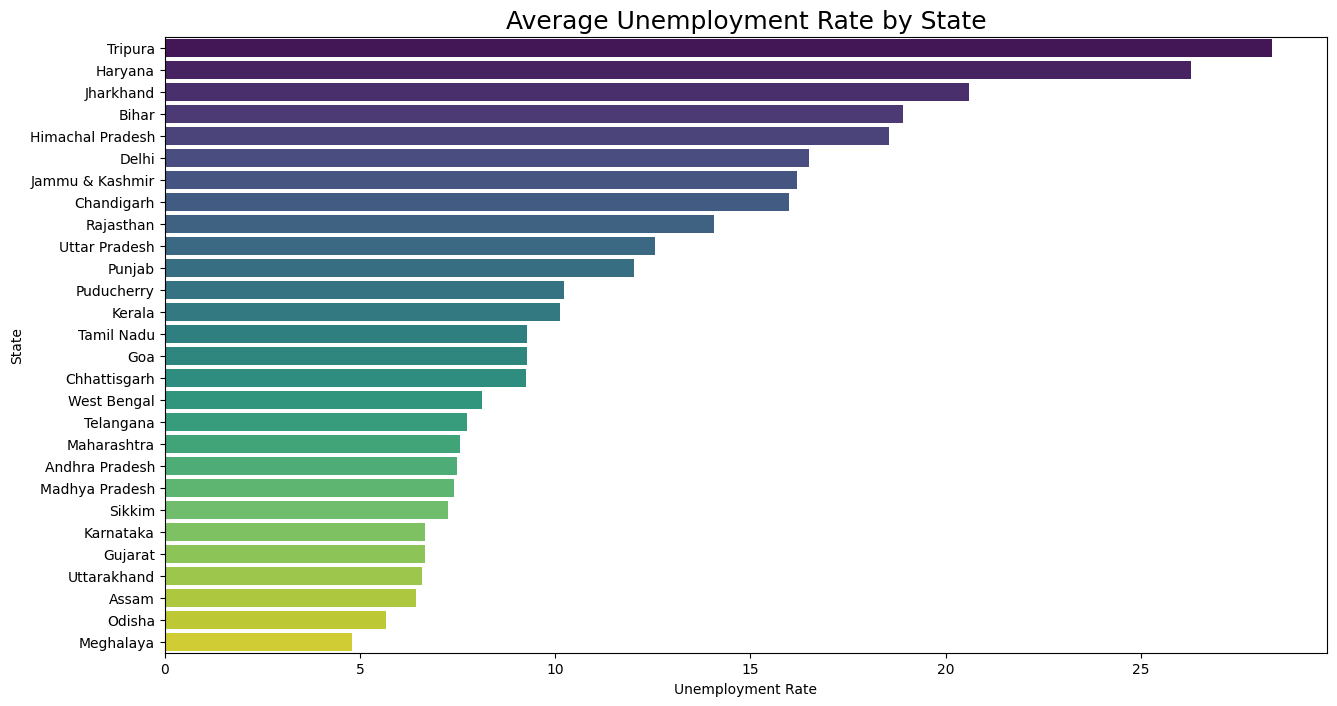

In [11]:
plt.figure(figsize=(15,8))

sns.barplot(
    x=avg_unemployment.values,
    y=avg_unemployment.index,
    palette='viridis'
)

plt.title("Average Unemployment Rate by State", fontsize=18)
plt.xlabel("Unemployment Rate")
plt.ylabel("State")

plt.show()

# Monthly Unemployement Trend

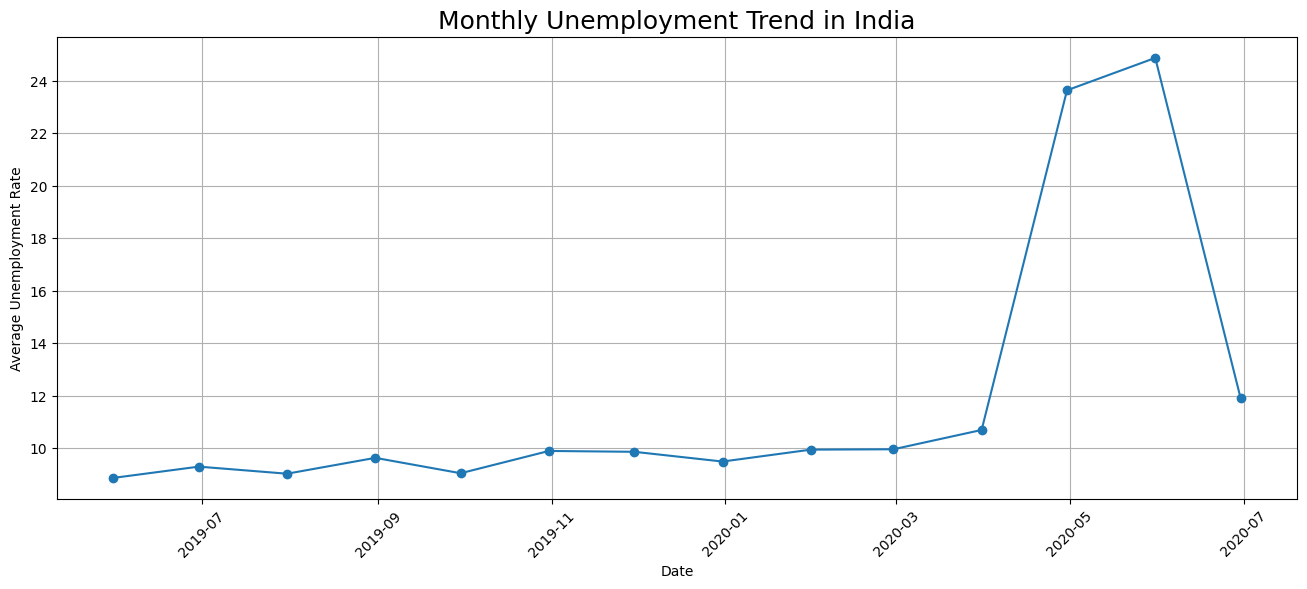

In [12]:
# Monthly Trend

monthly_trend = df.groupby('Date')['Estimated_Unemployment_Rate'].mean()

plt.figure(figsize=(16,6))

plt.plot(monthly_trend.index,
         monthly_trend.values,
         marker='o')

plt.title("Monthly Unemployment Trend in India", fontsize=18)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate")

plt.xticks(rotation=45)

plt.grid()

plt.show()

# Covid-19 Impact Analysis

In [13]:
# Covid Period

df['Year'] = df['Date'].dt.year

df['Covid_Period'] = np.where(df['Year'] >= 2020,
                              'During Covid',
                              'Before Covid')

df.head()

,Region,Date,Frequency,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Area,Year,Covid_Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,Before Covid
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,Before Covid
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,Before Covid
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,Before Covid
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,Before Covid


In [14]:
covid_analysis = df.groupby('Covid_Period')['Estimated_Unemployment_Rate'].mean()

covid_analysis

Covid_Period
Before Covid     9.399047
During Covid    15.101581
Name: Estimated_Unemployment_Rate, dtype: float64

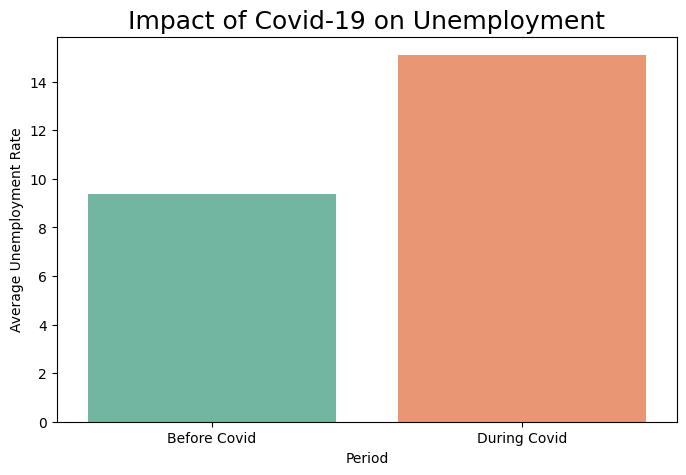

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values,
    palette='Set2'
)

plt.title("Impact of Covid-19 on Unemployment", fontsize=18)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate")

plt.show()

# Area-wise Analysis

In [16]:
# Area wise unemployment

area_analysis = df.groupby('Area')['Estimated_Unemployment_Rate'].mean()

area_analysis

Area
Rural    10.324791
Urban    13.166614
Name: Estimated_Unemployment_Rate, dtype: float64

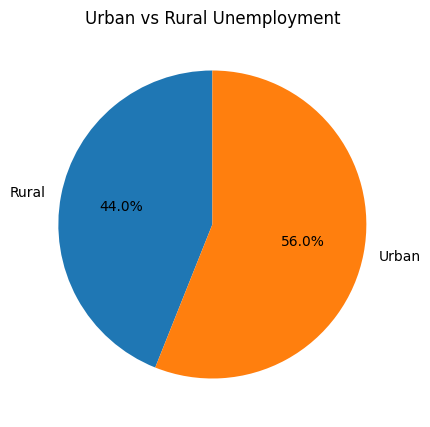

In [17]:
plt.figure(figsize=(7,5))

plt.pie(
    area_analysis.values,
    labels=area_analysis.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Urban vs Rural Unemployment")

plt.show()

# Heat Map Analysis

In [18]:
# Correlation Matrix

corr = df[['Estimated_Unemployment_Rate',
           'Estimated_Employed',
           'Estimated_Labour_Participation_Rate']].corr()

corr

,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate
Estimated_Unemployment_Rate,1.000000,-0.222876,0.002558
Estimated_Employed,-0.222876,1.000000,0.011300
Estimated_Labour_Participation_Rate,0.002558,0.011300,1.000000


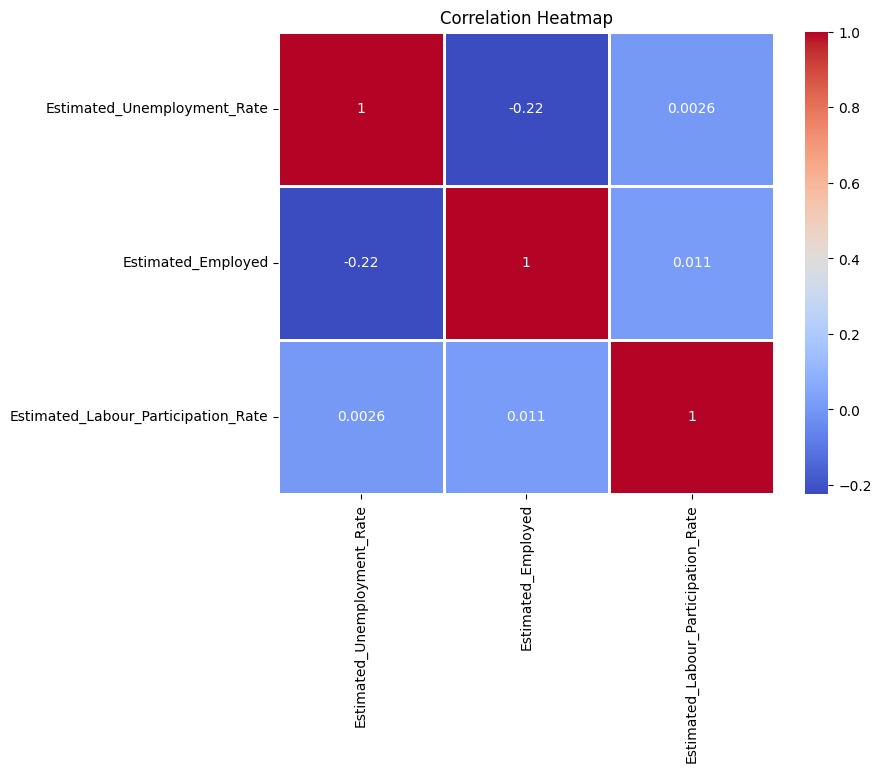

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

# Top 10 states with highest Unemployment

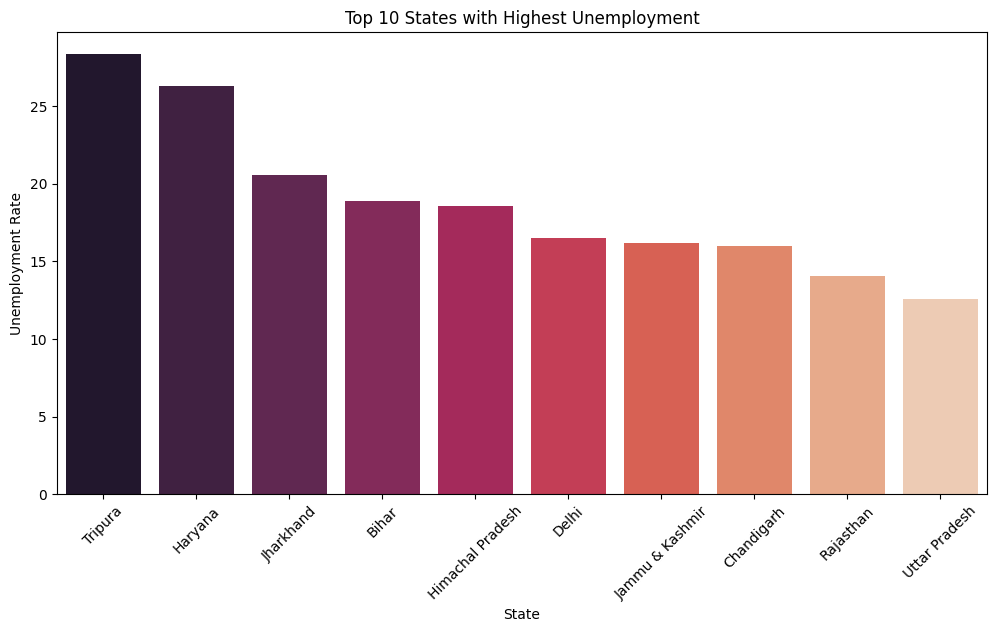

In [20]:
top_states = avg_unemployment.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values,
    palette='rocket'
)

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("State")
plt.ylabel("Unemployment Rate")

plt.xticks(rotation=45)

plt.show()

# Distribution Plot

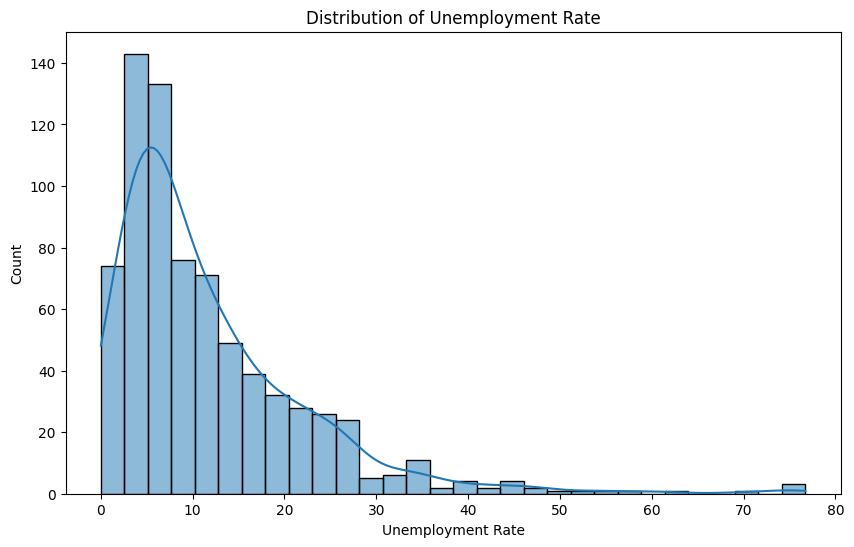

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated_Unemployment_Rate'],
    kde=True,
    bins=30
)

plt.title("Distribution of Unemployment Rate")

plt.xlabel("Unemployment Rate")

plt.show()

# Pairplot

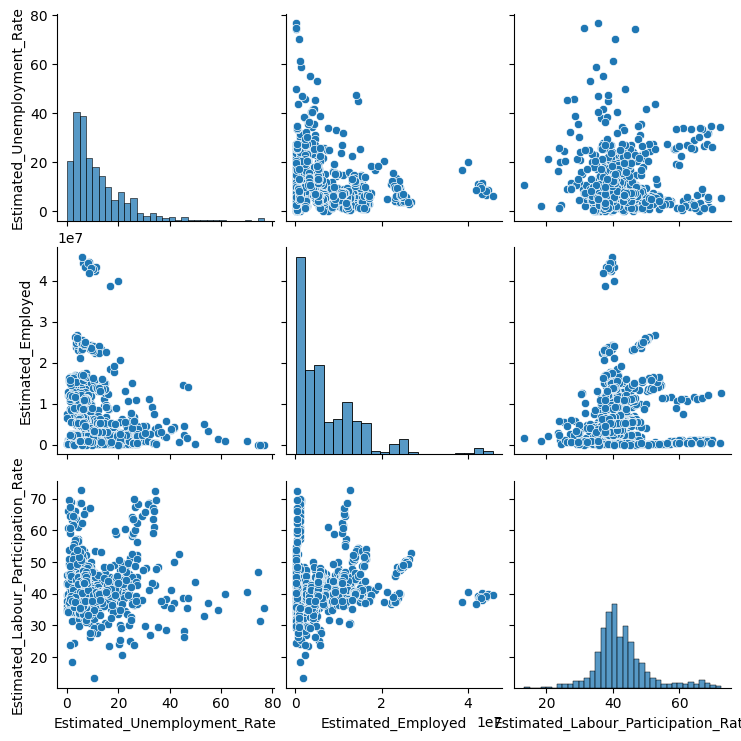

In [22]:
sns.pairplot(df[[
    'Estimated_Unemployment_Rate',
    'Estimated_Employed',
    'Estimated_Labour_Participation_Rate'
]])

plt.show()

# Key Insights

In [23]:
print("KEY INSIGHTS")
print()

print("1. Some states have significantly higher unemployment rates.")
print("2. Covid-19 caused a major increase in unemployment.")
print("3. Urban unemployment differs from rural unemployment.")
print("4. Employment and labour participation are strongly related.")
print("5. Seasonal unemployment trends are visible in the dataset.")

KEY INSIGHTS

1. Some states have significantly higher unemployment rates.
2. Covid-19 caused a major increase in unemployment.
3. Urban unemployment differs from rural unemployment.
4. Employment and labour participation are strongly related.
5. Seasonal unemployment trends are visible in the dataset.


# Conclusion

In [24]:
print("""
Conclusion:

This project analyzed unemployment trends in India using Python.

Main tasks performed:
- Data Cleaning
- Exploratory Data Analysis
- Covid-19 Impact Analysis
- Data Visualization

The analysis showed that unemployment increased sharply during Covid-19.
Different states and regions were affected differently.

This project helps understand economic conditions and can support policy decisions.
""")


Conclusion:

This project analyzed unemployment trends in India using Python.

Main tasks performed:
- Data Cleaning
- Exploratory Data Analysis
- Covid-19 Impact Analysis
- Data Visualization

The analysis showed that unemployment increased sharply during Covid-19.
Different states and regions were affected differently.

This project helps understand economic conditions and can support policy decisions.

